# Adım 4 — Detection-vs-Intensity Eğrisi (headline sonuç)

**Amaç:** Her atak tipinde **yoğunluk düştükçe tespit nasıl değişiyor?** Bu, projenin
asıl merak ettiği ve raporun kapak sonucu olan eğri.

**Kavram — "tespit oranı" = belirli yoğunlukta recall.** Bir yoğunluk kutusundaki
(ör. grey p=0.2) tüm koşuları al, kaçının doğru işaretlendiğini oranla. Bu oranı
yoğunluğa karşı çizersek eğriyi elde ederiz. Düşük yoğunlukta feature'lar normale
yakınsar → tespit **düşmesi beklenir**; eğri bu "tespit tabanını" gösterir.

**İki eğri çiziyoruz:**
- **Binary tespit-recall (asıl):** koşu "atak" olarak işaretlendi mi? (tip önemli değil)
- **Multiclass doğru-sınıf oranı (bonus):** koşu **kendi** tipine mi atandı? (dos, dos'a mı?)

Binary "atağı gördün mü", multiclass "tipini de bildin mi" sorusudur; ikisinin arası
tam da modelin zorlandığı yeri (ör. dos↔ddos) açığa çıkarır.

**Eksenler atak-başına ayrı:** birimler kıyaslanamaz, o yüzden tek grafik değil
3 panel — grey→teslim ekseni (p), DoS→flood hızı, DDoS→saldırgan sayısı. Blackhole,
grey'in teslim ekseninin **p=1.0 ucu** olarak grey paneline eklenir (tam-ret = grey p=1).

> Tahminler Adım 3'teki **aynı** modelden ve **aynı** CV'den (OOF) gelir → confusion
> matrix ile birebir tutarlı.

In [1]:
# --- Kütüphaneler ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_val_predict   # Adım 3'teki OOF şemasının aynısı
from sklearn.ensemble import RandomForestClassifier                      # Adım 3'te seçilen model (yorumlanabilirlik)

# --- veri + X/y (Adım 1/3 ile birebir aynı kurulum) ---
# iki aday yol: notebook repo kökünden mi yoksa kendi klasöründen mi açıldı, ikisinde de
# çalışsın diye ilk var olan dosyayı seçiyoruz
cands = [Path("my-work/day3-4-08072026-09072026-dataset/out/dataset.csv"),
         Path("../day3-4-08072026-09072026-dataset/out/dataset.csv")]
DATA = next((p for p in cands if p.exists()), None)
assert DATA is not None, "dataset.csv bulunamadi"
df = pd.read_csv(DATA)

# --- Stealth prob seti: EGITIMDE YOK (bkz. adim 5) ---
# Feature vektoru normalle ozdes olan bir config egitim sinifi olamaz: tek vektore iki
# etiket = etiket gurultusu. dos rate<10'un floodu 1-5 pkt/s; ayni seed'deki normalle
# eslestirilince teslim farki -0.003, throughput farki -0.07 Mbps (=hicbir sey), tek fark
# n_flows +1. OLCULDU: egitime katinca yanlis alarm %12.5 -> %35, macro-F1 0.809 -> 0.741.
# Egrinin tabanini olcmek icin gerekliler, ama orada da EGITILMEDEN degerlendiriliyorlar.
# Ayni kural grey p=0'a da uygulaniyor (o hic dataset'e girmiyor).
PROBE = (df.scenario == "dos") & (df.intensity < 10)
pr = df[PROBE].copy()                       # egitimde YOK, egrinin tabani icin degerlendirilir
df = df[~PROBE].reset_index(drop=True)

# Feature listesi burada TANIMLANMIYOR, my-work/detector_schema.py'den geliyor.
# Kopyalanmis listeler birbirinden ayrilmisti: 02-07 bu ozellik eklenmeden once yazildi
# (12 girdi), 08-10 sonra (13), yayimlanan model 13. check_against_release() semayi
# yayimlanan manifest'e karsi dogruluyor -- buradaki sayilar teslim edilmis modeli
# anlatmiyorsa hucre patlar.
import sys
for _p in ("my-work", "..", "../.."):
    if (Path(_p)/"detector_schema.py").exists(): sys.path.insert(0, _p); break
from detector_schema import FEATURES, build_X, check_against_release
_rel = check_against_release()
print(f"sema surum {_rel['version']} ile uyusuyor ({len(_rel['model']['features'])} girdi)")
X = build_X(df)
y = df["label_class"]

# --- Adım 3'teki modeli + CV'yi birebir kur, OOF tahmini üret ---
# neden birebir aynı: bu eğri Adım 3'ün confusion matrix'iyle tutarlı olmalı — farklı bir
# model/CV kullanırsak sayılar örtüşmez ve "aynı modelin farklı görünümü" iddiası çürür
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
rf  = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=0)
oof = cross_val_predict(rf, X, y, cv=skf)                 # her koşuya, test olduğu fold'dan tahmin

# tahminleri df'e iliştir (yoğunluk metadata'sıyla gruplayabilmek için)
df = df.assign(pred=oof)
print("OOF tahmin üretildi:", df["pred"].shape[0], "koşu")
print("Adım 3 ile tutarlılık — genel doğruluk:", round((df["pred"] == y).mean(), 4))

sema surum v1.1 ile uyusuyor (13 girdi)


OOF tahmin üretildi: 255 koşu
Adım 3 ile tutarlılık — genel doğruluk: 0.8549


## 1. Yoğunluk kutusu başına tespit oranlarını hesapla

Her `(scenario, intensity)` kutusu için iki oran:
- **binary tespit-recall** = kutudaki koşuların `pred != "normal"` olan kesri (atak olarak yakalandı mı),
- **multiclass doğru-sınıf** = `pred == scenario` olan kesri (kendi tipine mi atandı).

`normal` bir atak yoğunluk ekseni olmadığından eğriye girmez; onun yerine referans olarak
**yanlış-alarm oranı**nı (normal iken atak denen kesir) ayrıca yazdırıyoruz.

In [2]:
from sklearn.base import clone
ATTACKS = ["greyhole", "dos", "ddos", "blackhole"]
d = df[df["scenario"].isin(ATTACKS)].copy()
# koşu-başı iki ikili gösterge — sonra kutu içinde ortalaması = oran
d["is_attack_pred"] = (d["pred"] != "normal").astype(int)          # atak olarak yakalandı mı
d["is_correct"]     = (d["pred"] == d["scenario"]).astype(int)     # kendi tipine mi atandı

curve = (d.groupby(["scenario", "intensity"])
           .agg(n=("pred", "size"),
                binary_detect=("is_attack_pred", "mean"),
                correct_class=("is_correct", "mean"))
           .reset_index())

# Prob noktalari (dos rate<10): egitimde hic yoklar, dolayisiyla OOF'lari da yok.
# Tum egitim setine fit edilmis detektorle tahmin ediliyorlar: 'gercek ataklarla
# egitilmis bir detektor, atak hicbir sey yapmayinca ne der?'. Egrinin tabani bu.
Xp = pr[FEATURES].copy(); Xp["monitor_missing"] = Xp["monitor_owd_ms"].isna().astype(int)
Xp = Xp.fillna(0.0)
probe_pred = clone(rf).fit(X, y).predict(Xp)
probe = (pr.assign(pred=probe_pred).groupby(["scenario", "intensity"])
           .agg(n=("pred", "size"),
                binary_detect=("pred", lambda s: (s != "normal").mean()),
                correct_class=("pred", lambda s: (s == "dos").mean()))
           .reset_index())
curve = pd.concat([curve, probe], ignore_index=True).sort_values(["scenario", "intensity"])

# Referans: normal koşularda yanlış-alarm (pred != normal) — eğrinin "taban gürültüsü"
fa = (df[df["scenario"] == "normal"]["pred"] != "normal").mean()
print(f"Yanlış-alarm oranı (normal → atak): {fa:.3f}  (0 = hiç yanlış alarm yok)\n")
curve

Yanlış-alarm oranı (normal → atak): 0.175  (0 = hiç yanlış alarm yok)



,scenario,intensity,n,binary_detect,correct_class
0,blackhole,1.00,10,1.0,1.0
1,ddos,1.00,5,1.0,0.0
2,ddos,2.00,5,1.0,0.8
3,ddos,3.00,5,1.0,1.0
4,ddos,5.00,5,1.0,1.0
5,ddos,8.00,5,1.0,0.6
24,dos,1.00,10,0.4,0.4
25,dos,2.00,10,0.2,0.2
26,dos,5.00,10,0.2,0.2
6,dos,10.00,10,0.3,0.3


## 2. Üç panel: teslim ekseni (grey+blackhole), flood hızı (DoS), saldırgan sayısı (DDoS)

Her panelde iki çizgi: **binary tespit** (atağı gördün mü) ve **doğru-sınıf** (tipini de bildin mi).
İkisinin ayrıştığı yer = model atağı görüyor ama tipini karıştırıyor demektir.

**Grey paneli teslim ekseni:** x = drop olasılığı `p`. Grey p=0.1..0.9'a **blackhole**'u p=1.0
noktası olarak ekliyoruz (tam-ret ucu) → eğri stealth (p küçük) uçtan tam-ret (p=1) uca uzanır.

Kaydedildi: figs/F-detection-vs-intensity.png


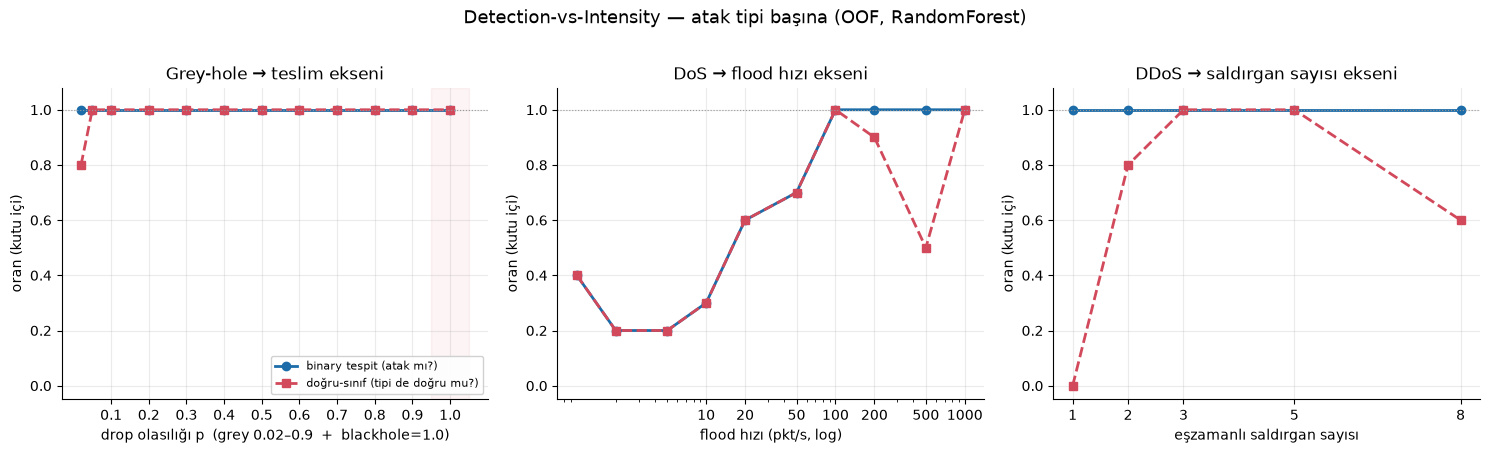

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

def panel(ax, sub, xlabel, title, logx=False, xticks=None):
    sub = sub.sort_values("intensity")
    ax.plot(sub["intensity"], sub["binary_detect"], "o-", color="#1b6ca8",
            label="binary tespit (atak mı?)", linewidth=2, markersize=6)
    ax.plot(sub["intensity"], sub["correct_class"], "s--", color="#d1495b",
            label="doğru-sınıf (tipi de doğru mu?)", linewidth=2, markersize=6)
    if logx:
        ax.set_xscale("log")   # DoS flood hızı 10..1000 aralığında çarpımsal artıyor (10x, 5x, 2x...);
                                 # doğrusal eksende düşük değerler sıkışıp görünmez olur, log açar
    if xticks is not None:
        ax.set_xticks(xticks); ax.set_xticklabels([str(t) for t in xticks])
    ax.axhline(1.0, color="#999", lw=0.8, ls=":")   # referans çizgi: "tam tespit" tavanı,
                                                      # eğrinin buna ne kadar yakın kaldığını göze çarptırır
    ax.set_ylim(-0.05, 1.08)
    ax.set_xlabel(xlabel); ax.set_ylabel("oran (kutu içi)")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

# --- Panel 1: teslim ekseni = grey (p 0.1-0.9) + blackhole (p=1.0) ---
grey = curve[curve["scenario"] == "greyhole"].copy()
black = curve[curve["scenario"] == "blackhole"].copy()   # intensity zaten 1.0
delivery = pd.concat([grey, black]).sort_values("intensity")
panel(axes[0], delivery, "drop olasılığı p  (grey 0.02–0.9  +  blackhole=1.0)",
      "Grey-hole → teslim ekseni",
      xticks=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0])
axes[0].axvspan(0.95, 1.05, color="#d1495b", alpha=0.06)   # blackhole ucu işareti

# --- Panel 2: DoS flood hızı (log x) ---
panel(axes[1], curve[curve["scenario"] == "dos"],
      "flood hızı (pkt/s, log)", "DoS → flood hızı ekseni",
      logx=True, xticks=[10,20,50,100,200,500,1000])

# --- Panel 3: DDoS saldırgan sayısı (küçük tam sayı aralığı, log gerekmiyor) ---
panel(axes[2], curve[curve["scenario"] == "ddos"],
      "eşzamanlı saldırgan sayısı", "DDoS → saldırgan sayısı ekseni",
      xticks=[1,2,3,5,8])

axes[0].legend(loc="lower right", fontsize=8, framealpha=0.9)
fig.suptitle("Detection-vs-Intensity — atak tipi başına (OOF, RandomForest)", fontsize=13, y=1.02)
fig.tight_layout()

FIGS = Path("figs"); FIGS.mkdir(exist_ok=True)
fig.savefig(FIGS / "F-detection-vs-intensity.png", dpi=150, bbox_inches="tight")
print("Kaydedildi: figs/F-detection-vs-intensity.png")
plt.show()

## 3. Yorum ve bulgular

Okurken bak:
- **Binary çizgisi (mavi) düşük yoğunlukta düşüyor mu?** Düşüyorsa headline elde edilmiş demektir: saldırı zayıfladıkça tespit çöküyor. DoS panelinde bu görünüyor — rate10'da ~0.40, rate100'den sonra 1.0. Bu, tabanın artık gerçek bir gürültü zemini olmasının sonucudur; steril veride aynı çizgi her yoğunlukta düz 1.0'dı.
- **Doğru-sınıf çizgisi (kırmızı) nerede ayrılıyor?** İki çizginin ayrıldığı yer = "atağı gördüm ama tipini karıştırdım". Beklenen bölge DoS↔DDoS: ikisi de flood ve tek güçlü flood ile birkaç zayıf flood aynı hacim imzasını bırakır. DDoS panelinde na=1'in 0'a düşmesi bunun uç hâli — tek saldırganlı DDoS tanım gereği DoS'tur.
- **Grey paneli — dikkat:** p=0.02'de binary ~0.80'e iniyor ama bu taban atağın değil **relay'in kendi izidir**. Kurban trafiği saldırgan üzerinden geçtiği için havayı 4 kez geçer (normalde 2) ve tıkanıklık altında bu fazladan adım tek başına 2.09σ'lık bir teslim farkı yaratır. Ölçüm: p=0 (saldırı kapalı) teslimi 0.9023 vs normal 0.9695. Atağın kendi etkisi p=0.02'de yalnız 0.08σ'dır. Yani grey kolu normale göre değil, benign-relay tabanına göre okunmalıdır.
- **DDoS paneli düz:** beklenen. Saldırgan başına flood hızı 100 pkt/s olduğu için na=1 bile zaten tespit edilebilir bölgededir; bu panelde stealth uç yoktur.
